Necessary imports

In [2]:
from random import expovariate # Generate variates from exponential distribution
import numpy as np
import pylab as p
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import fsolve
import sympy as sym

Find the equilibria of the system and determine their stability.

100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
[100. 100. 100. ... 100. 100. 100.]


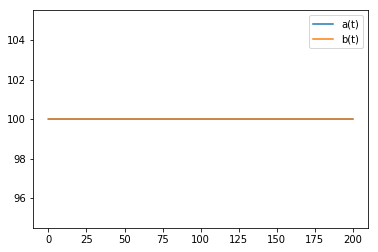

[-1.50000000e+00 -1.45000000e+00 -1.40000000e+00 -1.35000000e+00
 -1.30000000e+00 -1.25000000e+00 -1.20000000e+00 -1.15000000e+00
 -1.10000000e+00 -1.05000000e+00 -1.00000000e+00 -9.50000000e-01
 -9.00000000e-01 -8.50000000e-01 -8.00000000e-01 -7.50000000e-01
 -7.00000000e-01 -6.50000000e-01 -6.00000000e-01 -5.50000000e-01
 -5.00000000e-01 -4.50000000e-01 -4.00000000e-01 -3.50000000e-01
 -3.00000000e-01 -2.50000000e-01 -2.00000000e-01 -1.50000000e-01
 -1.00000000e-01 -5.00000000e-02  1.33226763e-15  5.00000000e-02
  1.00000000e-01  1.50000000e-01  2.00000000e-01  2.50000000e-01
  3.00000000e-01  3.50000000e-01  4.00000000e-01  4.50000000e-01
  5.00000000e-01  5.50000000e-01  6.00000000e-01  6.50000000e-01
  7.00000000e-01  7.50000000e-01  8.00000000e-01  8.50000000e-01
  9.00000000e-01  9.50000000e-01  1.00000000e+00  1.05000000e+00
  1.10000000e+00  1.15000000e+00  1.20000000e+00  1.25000000e+00
  1.30000000e+00  1.35000000e+00  1.40000000e+00  1.45000000e+00]


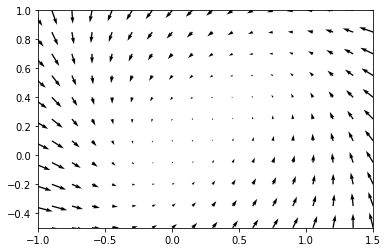

In [13]:
# define system in terms of ODEs - adot and bdot
'''
def Adot(A,B):
    return (-beta/N)*B*A + gamma*B
def Bdot(A,B):
    return (beta/N)*B*A - gamma*B
'''
def dydt_FHN(Y,t,beta,gamma,N):
    A = Y[0];
    print(A)
    B = Y[1];
    #below is a list containing each ODE
    dydt = [-beta*(B/N)*A + gamma*B, beta*(B/N)*A - gamma*B] 
    return dydt
'''
# initialize lists containing values
A = []
B = []
'''
# initial values
a0 = 100
b0 = 100
Y0 = np.array([a0,b0]) # initial position
t = np.arange(0,200,0.1) # time # 0.1 (the increment is our 'h')
# parameters
beta = 0.04
gamma = 0.02
N = 200
#not actually sure??
d = 1
I0 = 0.1
# Here we use Python's built-in ODE solver to integrate the system
Y = odeint(dydt_FHN,Y0,t,args=(beta,gamma,N))

'''
#iv1, iv2 = initial values, dt = timestep, time = range
def sys(a0, b0, dt, time):
    
    # initial values:
    A.append(a0)
    B.append(b0)
    
    # compute and fill lists
     
    #for a length of time (in this case 1000), add initial values to the respective ODE and then multiply by timestep
    
    for i in range(time):
        A.append(A[i] + (Adot(A[i],B[i])) * dt)
        B.append(B[i] + (Bdot(A[i],B[i])) * dt)
    return A, B

print('initial condition values were {} and {}. '.format(a0, b0))
sys(a0, b0, 0.01, 1000)
'''
# Plotting time course
#xlabel('Time'); ylabel('a, b')
plt.figure()
print(Y[:,0])
plt.plot(t,Y[:,0],t,Y[:,1]) # time courses of a and b
plt.legend(('a(t)','b(t)'));
plt.show()

#--------->
# trajectories are plotted in the phase plane below
vpts=np.arange(-1.5,1.5,.05) #this an arbitrary amount for arrange? #vpts (possibly vector pts?)
plt.figure()
plt.plot(Y[:,0],Y[:,1]) # a-b phase plane 
plt.axis([-1,1.5,-.5,1]) #xandy-axis

## determine and plot the a,b-nullclines
#anullpts=vpts/beta
#anullpts=-vpts*(vpts-gamma)*(vpts-1)+I0
#plt.plot(vpts,anullpts,'k',vpts,bnullpts,'k')

#intialise and plot a and b nullclines
#these were solved analytically
bnullpts = 0
anullpts = (N*gamma)/beta
plt.plot(-anullpts,anullpts,-bnullpts,bnullpts)

eps = 1.0;
[x,y] = np.meshgrid(np.arange(-1.5,1.65,0.15),np.arange(-0.5,1.15,0.15))
px = -x*(x-gamma)*(x-1)-y+I0
py = eps*(x-d*y)
plt.quiver(x,y,px,py)

'''
#plot
fig = plt.figure(figsize=(15,5))
fig.subplots_adjust(wspace = 0.5, hspace = 0.3)
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.plot(A, 'r-', label='Avalues')
ax1.plot(B, 'b-', label='Bvalues')
ax1.set_title("Dynamics in time")
ax1.set_xlabel("time")
ax1.grid()
ax1.legend(loc='best')

ax2.plot(A, B, color="blue")
ax2.set_xlabel("A")
ax2.set_ylabel("B")  
ax2.set_title("Phase space")
ax2.grid()
'''
print(vpts)

In [7]:
# define system in terms of a Numpy array
def Sys(Y, t=0, A, B):
    # here Y[0] = x and x[1] = y    
    return np.array([ (-beta/N)*B*A + gamma*B,  (beta/N)*B*A - gamma*B])

A = 50 
B = 50
# initial values
a0 = 50
b0 = 50
Y0 = np.array([a0,b0]) # initial position
t = np.arange(0,400,0.1) # time # 0.1 (the increment is our 'h')
# parameters
beta = 0.04
gamma = 0.02
N = 100

# generate 1000 linearly spaced numbers for x-axes
t = np.linspace(0, 20,  1000)

# initial values: x0 = 10, y0 = 2
Sys0 = np.array([a0, b0])

# use odeint to get integration from our ODEs
Y = odeint(Sys, Sys0, t, args=(A, B), full_output=True)



x,y = Y.T

#plot
fig = plt.figure(figsize=(15,5))
fig.subplots_adjust(wspace = 0.5, hspace = 0.3)
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.plot(x, 'r-', label='predator')
ax1.plot(y, 'b-', label='prey')
ax1.set_title("Dynamics in time")
ax1.set_xlabel("time")
ax1.grid()
ax1.legend(loc='best')

ax2.plot(x, y, color="blue")
ax2.set_xlabel("x")
ax2.set_ylabel("y")  
ax2.set_title("Phase space")
ax2.grid()

SyntaxError: non-default argument follows default argument (<ipython-input-7-965012d5a773>, line 2)